# Re-entraînement LSTM — Dataset avec Loss Effective

## Pourquoi re-entraîner ?
L'ancien dataset (`all_simu5g.csv`) avait `Slice_Packet_Loss_pct = 0%` **partout** (backpressure Simu5G).
Le nouveau dataset (`all_simu5g_with_loss.csv`) utilise la **loss effective proportionnelle** :
$$\text{loss} = \min\left(100, \max\left(0, \frac{\text{latence} - \text{SLA}_{\max}}{\text{SLA}_{\max}} \times 100\right)\right)$$

La feature `Slice_Packet_Loss_pct` apporte maintenant une **vraie information discriminante** au modèle.

## Architecture (identique à ml_lstm_fdl.ipynb)
- **Encodeur** : LSTM bidirectionnel (3 couches, 256 hidden)
- **Décodeur** : LSTM + Bahdanau Attention
- **Entrée** : 30s × 15 features | **Sortie** : 15s × 3 cibles
- **FedAvg** : LoGO (Leave-one-gNB-out) + modèle global
- **Modèles** sauvegardés dans `../../models_lstm_fdl_v2/`

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, sys, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
warnings.filterwarnings('ignore')

# ── Chemins ──────────────────────────────────────────────────────────────────
DATA_PATH  = '/content/drive/MyDrive/Colab Notebooks/all_simu5g_trans.csv'   # dataset enrichi avec scenarios de transition
MODELS_DIR = '/content/drive/MyDrive/Colab Notebooks/models_lstm_v3'
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Hyperparamètres ───────────────────────────────────────────────────────────
QUICK_MODE = False   # True pour test rapide (~20 min), False pour full

INPUT_SEC  = 60      # 60s de contexte (était 30) → meilleure détection de régime
OUTPUT_SEC = 15
LAT_CLIP   = 600_000.0

FEDPROX_MU = 0.01    # FedProx : terme proximal μ (Li et al., 2020)

FEATURES_RAW  = ['Slice_Throughput_Mbps', 'Slice_Latency_ms',
                 'Slice_Packet_Loss_pct', 'Slice_Jitter_ms',
                 'Slice_Network_Load_pct']
FEATURES_PROC = ['Slice_Throughput_Mbps', 'Slice_Latency_log1p',
                 'Slice_Packet_Loss_pct', 'Slice_Jitter_log1p',
                 'Slice_Network_Load_pct']
N_IN  = 15   # 5 features × (orig + trend + vol)
N_OUT = 3    # throughput, latency, loss

GNB_IDS = ['Macro', 'Commerce', 'Industrie']
SLICES  = ['eMBB', 'URLLC', 'mMTC']

# SLA : latence + perte (3GPP TS 28.554)
SLA = {
    'eMBB':  {'latency_max':  50.0, 'loss_max':  1.0},
    'URLLC': {'latency_max':  20.0, 'loss_max':  0.001},
    'mMTC':  {'latency_max':   8.8, 'loss_max':  1.0},
}

if QUICK_MODE:
    HIDDEN_SIZE, NUM_LAYERS, DROPOUT = 128, 2, 0.2
    EPOCHS, PATIENCE, BATCH_SIZE, FL_LOCAL_EPOCHS = 30, 10, 128, 5
    print('QUICK_MODE — validation rapide')
else:
    HIDDEN_SIZE, NUM_LAYERS, DROPOUT = 256, 3, 0.25
    EPOCHS, PATIENCE, BATCH_SIZE, FL_LOCAL_EPOCHS = 200, 30, 256, 50
    print('FULL MODE — entrainement complet')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device      : {device}')
print(f'Dataset     : {DATA_PATH}')
print(f'Models      : {MODELS_DIR}/')
print(f'Input window: {INPUT_SEC}s  |  FedProx μ={FEDPROX_MU}')

FULL MODE — entrainement complet
Device      : cuda
Dataset     : /content/drive/MyDrive/Colab Notebooks/all_simu5g_trans.csv
Models      : /content/drive/MyDrive/Colab Notebooks/models_lstm_v3/
Input window: 60s  |  FedProx μ=0.01


## 1. Chargement et feature engineering

In [ ]:
df_raw = pd.read_csv(DATA_PATH)
print(f'Lignes : {len(df_raw):,} | Scenarios : {df_raw["Scenario"].nunique()}')

# Tri chronologique
df_raw['t'] = pd.to_datetime(df_raw['Time_Sec'], utc=True, errors='coerce')
df_raw = df_raw.sort_values(['Slice_Type','gNB_id','Scenario','t']).reset_index(drop=True)

# Log1p transforms
df_raw['Slice_Latency_log1p'] = np.log1p(df_raw['Slice_Latency_ms'].clip(0, LAT_CLIP))
df_raw['Slice_Jitter_log1p']  = np.log1p(df_raw['Slice_Jitter_ms'].clip(0, LAT_CLIP))

# Features engineerées : trend (diff) + volatilité (rolling std)
engineered = {}
for col in FEATURES_PROC:
    engineered[col+'_trend'] = df_raw.groupby(['Slice_Type','gNB_id','Scenario'])[col].diff().fillna(0)
    engineered[col+'_vol']   = df_raw.groupby(['Slice_Type','gNB_id','Scenario'])[col]\
                                     .transform(lambda x: x.rolling(5, min_periods=1).std()).fillna(0)
for k,v in engineered.items():
    df_raw[k] = v

ALL_FEATURES = FEATURES_PROC + [f+sfx for f in FEATURES_PROC for sfx in ['_trend','_vol']]
assert len(ALL_FEATURES) == N_IN, f'N_IN mismatch: {len(ALL_FEATURES)} vs {N_IN}'

TARGET_COLS = ['Slice_Throughput_Mbps', 'Slice_Latency_log1p', 'Slice_Packet_Loss_pct']
print(f'Features: {N_IN} | Targets: {len(TARGET_COLS)}')
print(f'\nEchantillon loss (non-zero): {(df_raw["Slice_Packet_Loss_pct"] > 0).mean()*100:.1f}% des lignes')

SCENARIOS = sorted(df_raw['Scenario'].unique().tolist())
print(f'Scenarios ({len(SCENARIOS)}) : {SCENARIOS}')

Lignes : 255,812 | Scenarios : 26
Features: 15 | Targets: 3

Echantillon loss (non-zero): 47.8% des lignes
Scenarios (26) : ['FifaWorldCup_Commerce', 'GlobalSaturation', 'HetLoad_Asymmetric_A', 'HetLoad_Asymmetric_B', 'HetLoad_Asymmetric_C', 'KddiOutage_Storm', 'LowTrafficNight', 'ModerateLoad_URLLC', 'ModerateLoad_eMBB', 'NormalLoad', 'OverloadeMBB_Commerce', 'SLABoundary_URLLC', 'Trans_Gradual_URLLC', 'Trans_Gradual_eMBB', 'Trans_Gradual_mMTC', 'Trans_LowViol_URLLC', 'Trans_LowViol_eMBB', 'Trans_LowViol_mMTC', 'Trans_Peak_URLLC', 'Trans_Peak_eMBB', 'Trans_RampDown_URLLC', 'Trans_RampDown_eMBB', 'Trans_RampDown_mMTC', 'Trans_RampUp_URLLC', 'Trans_RampUp_eMBB', 'Trans_RampUp_mMTC']


## 2. Scalers et datasets

In [ ]:
# Scaler GLOBAL par slice (fitté sur tous les gNBs combinés).
# Garantit que train et test vivent dans le même espace normalisé,
# indépendamment du gNB source — indispensable pour la généralisation LoGO.
scalers = {}
for sl in SLICES:
    sub = df_raw[df_raw['Slice_Type'] == sl]
    sc_x = StandardScaler().fit(sub[ALL_FEATURES])
    sc_y = StandardScaler().fit(sub[TARGET_COLS])
    for gid in GNB_IDS:
        scalers[(sl, gid)] = {'x': sc_x, 'y': sc_y}   # même scaler pour tous les gNBs
print(f'Scalers crees: {len(scalers)} (1 scaler global par slice, partage entre gNBs)')


class SliceDataset(Dataset):
    """
    Fenêtres glissantes (X: win_in s, Y: win_out s).
    Stocke var_weights = std(latence brute sur la fenêtre X) pour
    l'échantillonnage pondéré par variance — favorise les fenêtres
    de transition plutôt que les régimes statiques.
    """
    def __init__(self, df, slice_name, gnb_ids, scenarios=None,
                 win_in=INPUT_SEC, win_out=OUTPUT_SEC):
        self.samples     = []
        self.var_weights = []   # std latence brute dans la fenêtre X

        for gid in gnb_ids:
            sub = df[(df['Slice_Type']==slice_name) & (df['gNB_id']==gid)]
            sc  = scalers[(slice_name, gid)]
            for sc_name, grp in sub.groupby('Scenario'):
                if scenarios is not None and sc_name not in scenarios:
                    continue
                grp      = grp.sort_values('t').reset_index(drop=True)
                lat_raw  = grp['Slice_Latency_ms'].values          # latence brute
                X_n      = sc['x'].transform(
                               grp[ALL_FEATURES].values).astype(np.float32)
                Y_n      = sc['y'].transform(
                               grp[TARGET_COLS].values).astype(np.float32)
                T = len(grp)
                for i in range(T - win_in - win_out):
                    self.samples.append((X_n[i:i+win_in],
                                         Y_n[i+win_in:i+win_in+win_out]))
                    # Poids = std(latence) sur la fenêtre d'entrée + ε
                    self.var_weights.append(
                        float(lat_raw[i:i+win_in].std()) + 1.0)

    def __len__(self):        return len(self.samples)
    def __getitem__(self, i): return self.samples[i]


def make_weighted_loader(dataset, batch_size, weighted=False):
    """
    DataLoader avec WeightedRandomSampler basé sur la variance de latence.
    Gère aussi bien les SliceDataset directs que les torch Subset.
    """
    if weighted:
        if isinstance(dataset, torch.utils.data.Subset):
            all_w   = np.array(dataset.dataset.var_weights)
            weights = all_w[dataset.indices]
        else:
            weights = np.array(dataset.var_weights)
        weights = weights / weights.sum()
        sampler = WeightedRandomSampler(
            weights=torch.DoubleTensor(weights),
            num_samples=len(dataset),
            replacement=True)
        return DataLoader(dataset, batch_size=batch_size,
                          sampler=sampler, num_workers=8, pin_memory=True, persistent_workers=True)
    return DataLoader(dataset, batch_size=batch_size,
                      shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True)


# Résumé
print('\n=== Fenetres disponibles par slice ===')
for sl in SLICES:
    ds  = SliceDataset(df_raw, sl, GNB_IDS)
    var = np.array(ds.var_weights)
    print(f'  {sl:6s}  {len(ds):,} fenetres  '
          f'| std_lat moy={var.mean():.1f}  max={var.max():.1f}')
print('\nDataset pret.')

Scalers crees: 9 (1 scaler global par slice, partage entre gNBs)

=== Fenetres disponibles par slice ===
  eMBB    86,463 fenetres  | std_lat moy=23.2  max=831.3
  URLLC   86,463 fenetres  | std_lat moy=6.9  max=549.4
  mMTC    71,636 fenetres  | std_lat moy=1.1  max=1.9

Dataset pret.


## 3. Architecture LSTM Seq2Seq + Bahdanau Attention

In [ ]:
class BahdanauAttention(nn.Module):
    def __init__(self, enc_dim, dec_dim, attn_dim=128):
        super().__init__()
        self.W_enc = nn.Linear(enc_dim, attn_dim, bias=False)
        self.W_dec = nn.Linear(dec_dim, attn_dim, bias=False)
        self.v     = nn.Linear(attn_dim, 1, bias=False)
    def forward(self, enc_out, dec_h):
        # enc_out: (B,T,enc_dim) | dec_h: (B,dec_dim)
        e = self.v(torch.tanh(self.W_enc(enc_out) + self.W_dec(dec_h).unsqueeze(1)))
        attn = torch.softmax(e, dim=1)          # (B,T,1)
        return (attn * enc_out).sum(dim=1)      # (B,enc_dim)

class LSTMEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout if num_layers>1 else 0,
                            bidirectional=True)
        self.proj_h = nn.Linear(hidden_size*2, hidden_size)
        self.proj_c = nn.Linear(hidden_size*2, hidden_size)
        self.num_layers, self.hidden_size = num_layers, hidden_size
    def forward(self, x):
        enc_out, (h, c) = self.lstm(x)
        h = h.view(self.num_layers, 2, -1, self.hidden_size)
        c = c.view(self.num_layers, 2, -1, self.hidden_size)
        h = self.proj_h(torch.cat([h[:,-2], h[:,-1]], dim=-1))
        c = self.proj_c(torch.cat([c[:,-2], c[:,-1]], dim=-1))
        return enc_out, (h.contiguous(), c.contiguous())

class LSTMDecoder(nn.Module):
    def __init__(self, output_size, hidden_size, num_layers, dropout):
        super().__init__()
        enc_dim = hidden_size * 2
        self.attn   = BahdanauAttention(enc_dim, hidden_size, attn_dim=128)
        self.lstm   = nn.LSTM(output_size+enc_dim, hidden_size, num_layers,
                              batch_first=True, dropout=dropout if num_layers>1 else 0)
        self.fc_out = nn.Linear(hidden_size+enc_dim, output_size)
        self.dropout = nn.Dropout(dropout)
    def forward(self, prev_pred, enc_out, h, c):
        dec_h    = h[-1]
        context  = self.attn(enc_out, dec_h)
        lstm_in  = torch.cat([prev_pred, context], dim=1).unsqueeze(1)
        lstm_out, (h, c) = self.lstm(lstm_in, (h, c))
        out = self.fc_out(self.dropout(torch.cat([lstm_out.squeeze(1), context], dim=1)))
        return out, h, c

class Seq2SeqLSTM(nn.Module):
    def __init__(self, n_in, n_out, hidden_size, num_layers, dropout):
        super().__init__()
        self.encoder = LSTMEncoder(n_in, hidden_size, num_layers, dropout)
        self.decoder = LSTMDecoder(n_out, hidden_size, num_layers, dropout)
        self.n_out   = n_out
    def forward(self, src, tgt=None, teacher_forcing=0.5):
        enc_out, (h, c) = self.encoder(src)
        B, T_out = src.size(0), (tgt.size(1) if tgt is not None else OUTPUT_SEC)
        outputs  = []
        inp = torch.zeros(B, self.n_out, device=src.device)
        for t in range(T_out):
            out, h, c = self.decoder(inp, enc_out, h, c)
            outputs.append(out.unsqueeze(1))
            inp = (tgt[:,t,:] if tgt is not None and torch.rand(1).item()<teacher_forcing else out)
        return torch.cat(outputs, dim=1)

def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)
test_m = Seq2SeqLSTM(N_IN, N_OUT, HIDDEN_SIZE, NUM_LAYERS, DROPOUT)
print(f'Parametres : {count_params(test_m):,}')

Parametres : 5,920,643


## 4. Boucle d'entraînement

In [ ]:
LOG_EVERY = 5 if QUICK_MODE else 10   # fréquence d'affichage epochs

def train_model(model, train_loader, val_loader, epochs, patience,
                tag='model', global_weights=None, mu=0.0):
    """
    Entraînement avec early stopping + monitoring.
    global_weights : state_dict du modèle global pour FedProx.
    mu             : coefficient FedProx (0 = FedAvg classique).
    """
    opt       = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    criterion = nn.HuberLoss()
    best_val, wait, history = float('inf'), 0, []
    prev_lr = opt.param_groups[0]['lr']

    gw = None
    if global_weights is not None and mu > 0:
        gw = {k: v.to(device) for k, v in global_weights.items()}

    for ep in range(1, epochs+1):
        model.train()
        tr_loss = 0
        for X, Y in train_loader:
            X, Y = X.to(device), Y.to(device)
            opt.zero_grad()
            pred = model(X, Y, teacher_forcing=max(0, 0.5 - ep/epochs))
            loss = criterion(pred, Y)

            # ── Terme proximal FedProx ────────────────────────────────────
            if gw is not None:
                prox = sum(
                    ((p - gw[n]) ** 2).sum()
                    for n, p in model.named_parameters() if n in gw)
                loss = loss + (mu / 2) * prox

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tr_loss += loss.item()
        tr_loss /= len(train_loader)

        model.eval()
        va_loss = 0
        with torch.no_grad():
            for X, Y in val_loader:
                va_loss += criterion(model(X.to(device)), Y.to(device)).item()
        va_loss /= len(val_loader)
        scheduler.step(va_loss)

        cur_lr  = opt.param_groups[0]['lr']
        lr_drop = cur_lr < prev_lr
        prev_lr = cur_lr

        improved = va_loss < best_val
        history.append((tr_loss, va_loss))

        # ── Affichage ─────────────────────────────────────────────────────
        if ep % LOG_EVERY == 0 or lr_drop or ep == 1:
            prox_tag = f' mu={mu}' if gw is not None else ''
            lr_tag   = f' lr={cur_lr:.1e}' + (' DOWN' if lr_drop else '')
            wait_tag = f' wait={wait}/{patience}'
            ok_tag   = ' *' if improved else ''
            print(f'  ep {ep:3d}/{epochs} | tr={tr_loss:.4f} val={va_loss:.4f}'
                  f' best={best_val:.4f}{ok_tag}{lr_tag}{wait_tag}{prox_tag}')

        # ── Détection divergence ──────────────────────────────────────────
        if ep == 20 and len(history) >= 2:
            init_val = history[0][1]
            if va_loss > 3 * init_val:
                print(f'  !! DIVERGENCE ep={ep}: val={va_loss:.4f} >> init={init_val:.4f}'
                      f' — verifier lr, donnees, batch_size')

        # ── Early stopping ────────────────────────────────────────────────
        if improved:
            best_val, wait = va_loss, 0
            torch.save(model.state_dict(), f'{MODELS_DIR}/{tag}_best.pt')
        else:
            wait += 1
            if wait >= patience:
                print(f'  Early stop ep {ep} | meilleure val={best_val:.4f}')
                break

    model.load_state_dict(torch.load(f'{MODELS_DIR}/{tag}_best.pt',
                                      map_location=device))
    return model, history

print(f'train_model pret — log every {LOG_EVERY} epochs | FedProx mu={FEDPROX_MU}')

train_model pret — log every 10 epochs | FedProx mu=0.01


=== SANITY CHECK (5 epochs eMBB) ===
  ep   1/5 | tr=0.0606 val=0.0038 best=inf * lr=1.0e-03 wait=0/10

[CHECK 1] Loss decroissante : OK  (0.0038 → 0.0023)
[CHECK 2] Latence predite moy=17.7 ms  vraie moy=18.1 ms  MAE=0.4 ms  → OK
[CHECK 3] val/train ratio : 0.09  → OK


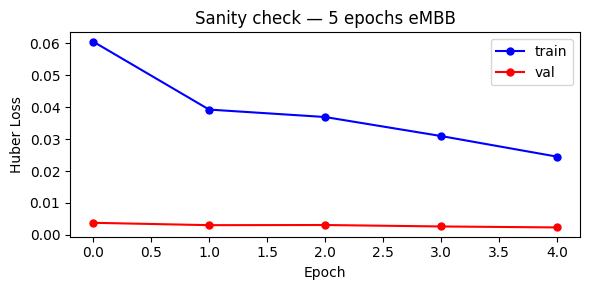


>> PASSE — lancer le LoGO complet  (41s)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SANITY CHECK — 5 epochs sur eMBB avant de lancer le vrai entraînement
# Valide que le pipeline (data → model → loss) fonctionne correctement.
# Si ce check échoue, inutile de lancer les 2-4h de LoGO.
# ══════════════════════════════════════════════════════════════════════════════
import time
print('=== SANITY CHECK (5 epochs eMBB) ===')
t0 = time.time()

_ds = SliceDataset(df_raw, 'eMBB', GNB_IDS)
_n  = max(1, int(len(_ds) * 0.15))
_tr, _va = torch.utils.data.random_split(_ds, [len(_ds) - _n, _n])
_tr_dl = make_weighted_loader(_tr, BATCH_SIZE, weighted=True)
_va_dl = make_weighted_loader(_va, BATCH_SIZE, weighted=False)

# Petite architecture pour aller vite (128 hidden, 2 couches)
_m = Seq2SeqLSTM(N_IN, N_OUT, 128, 2, 0.2).to(device)
_m, _hist = train_model(_m, _tr_dl, _va_dl,
                         epochs=5, patience=10, tag='_sanity')

# ── Check 1 : la loss diminue ─────────────────────────────────────────────
init_val  = _hist[0][1]
final_val = _hist[-1][1]
ok_loss   = final_val < init_val
print(f'\n[CHECK 1] Loss decroissante : {"OK" if ok_loss else "FAIL"}'
      f'  ({init_val:.4f} → {final_val:.4f})')

# ── Check 2 : prédictions dans un range réaliste ──────────────────────────
_m.eval()
sc_y = scalers[('eMBB', 'Macro')]['y']
with torch.no_grad():
    for X_b, Y_b in _va_dl:
        pred_n = _m(X_b.to(device)).cpu().numpy()
        true_n = Y_b.numpy()
        break

p_inv   = sc_y.inverse_transform(pred_n[0])
t_inv   = sc_y.inverse_transform(true_n[0])
p_lat   = np.expm1(p_inv[:, 1])   # latence prédite (ms)
t_lat   = np.expm1(t_inv[:, 1])   # latence vraie   (ms)
mae_lat = float(np.abs(p_lat - t_lat).mean())
ok_range = (0 < p_lat.mean() < 100_000)  # plausible pour une simulation réseau
print(f'[CHECK 2] Latence predite moy={p_lat.mean():.1f} ms  '
      f'vraie moy={t_lat.mean():.1f} ms  MAE={mae_lat:.1f} ms'
      f'  → {"OK" if ok_range else "HORS RANGE — probleme inverse_transform"}')

# ── Check 3 : overfitting brutal dès ep 1 ? ──────────────────────────────
ratio = _hist[-1][1] / max(_hist[-1][0], 1e-9)
ok_ratio = ratio < 5.0   # val ne dépasse pas 5× train
print(f'[CHECK 3] val/train ratio : {ratio:.2f}'
      f'  → {"OK" if ok_ratio else "ATTENTION — val >> train (overfitting)"}')

# ── Courbe loss ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot([h[0] for h in _hist], 'b-o', label='train', ms=5)
ax.plot([h[1] for h in _hist], 'r-o', label='val',   ms=5)
ax.set_xlabel('Epoch'); ax.set_ylabel('Huber Loss')
ax.set_title('Sanity check — 5 epochs eMBB')
ax.legend(); plt.tight_layout(); plt.show()

# ── Verdict ───────────────────────────────────────────────────────────────
elapsed = time.time() - t0
all_ok  = ok_loss and ok_range and ok_ratio
verdict = 'PASSE' if all_ok else 'ECHOUE'
print(f'\n{">> " + verdict + " — lancer le LoGO complet" if all_ok else "!! " + verdict + " — corriger avant de continuer"}'
      f'  ({elapsed:.0f}s)')
if not all_ok:
    raise RuntimeError('Sanity check échoué — stopper ici et corriger le problème.')

In [ ]:
import os
print(os.cpu_count())  # vois combien tu as

26


=== Split temporel 80/20 ===
  eMBB    train=68,403  test=17,295
  URLLC   train=68,403  test=17,295
  mMTC    train=56,586  test=14,330


=== Slice : eMBB ===
  Fenetres : train=58,143 | val=10,260 | test=17,295

  [Local] gNB=Macro
  ep   1/50 | tr=0.0656 val=0.0220 best=inf * lr=1.0e-03 wait=0/5
  ep  10/50 | tr=0.0013 val=0.0059 best=0.0060 * lr=1.0e-03 wait=0/5
  ep  20/50 | tr=0.0012 val=0.0048 best=0.0046 lr=1.0e-03 wait=3/5
  Early stop ep 21 | meilleure val=0.0046

  [Local] gNB=Commerce
  ep   1/50 | tr=0.0717 val=0.0200 best=inf * lr=1.0e-03 wait=0/5
  ep  10/50 | tr=0.0009 val=0.0116 best=0.0097 lr=1.0e-03 wait=0/5
  ep  20/50 | tr=0.0007 val=0.0057 best=0.0063 * lr=1.0e-03 wait=1/5
  ep  30/50 | tr=0.0007 val=0.0051 best=0.0048 lr=1.0e-03 wait=3/5
  ep  40/50 | tr=0.0006 val=0.0040 best=0.0040 lr=1.0e-03 wait=1/5
  Early stop ep 46 | meilleure val=0.0038

  [Local] gNB=Industrie
  ep   1/50 | tr=0.0950 val=0.0284 best=inf * lr=1.0e-03 wait=0/5
  ep  10/50 | tr=0.0212 val=0

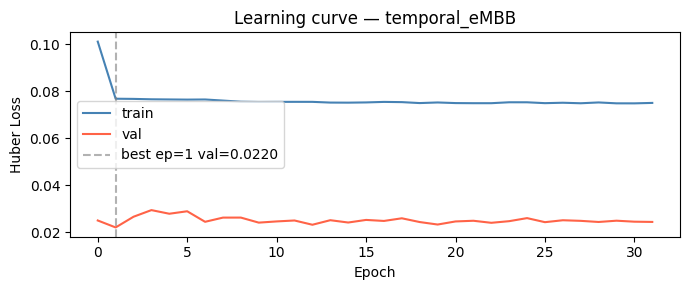


  >> eMBB
     [KPI]  MAE lat=43.81ms  |  MAE loss=4.305%  |  MAE thr=0.202Mbps
     [SLA]  F1=0.866  |  Recall=1.000  |  Precision=0.764  |  Specificity=0.586  |  viol_rate=57.3%

=== Slice : URLLC ===
  Fenetres : train=58,143 | val=10,260 | test=17,295

  [Local] gNB=Macro
  ep   1/50 | tr=0.0338 val=0.0061 best=inf * lr=1.0e-03 wait=0/5
  ep  10/50 | tr=0.0007 val=0.0025 best=0.0021 lr=1.0e-03 wait=1/5
  Early stop ep 13 | meilleure val=0.0021

  [Local] gNB=Commerce
  ep   1/50 | tr=0.0620 val=0.0112 best=inf * lr=1.0e-03 wait=0/5
  ep  10/50 | tr=0.0012 val=0.0078 best=0.0073 lr=1.0e-03 wait=1/5
  Early stop ep 13 | meilleure val=0.0073

  [Local] gNB=Industrie
  ep   1/50 | tr=0.0510 val=0.0170 best=inf * lr=1.0e-03 wait=0/5
  ep  10/50 | tr=0.0089 val=0.0100 best=0.0094 lr=1.0e-03 wait=0/5
  Early stop ep 19 | meilleure val=0.0087

  [FedAvg] agregation de 3 modeles locaux

  [FedProx fine-tune] slice=URLLC
  ep   1/200 | tr=0.0789 val=0.0101 best=inf * lr=1.0e-03 wait=0/30 mu

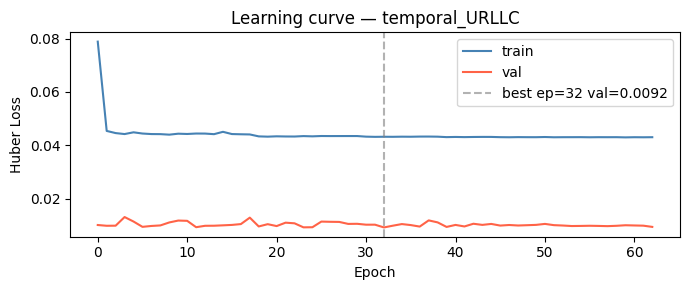


  >> URLLC
     [KPI]  MAE lat=28.68ms  |  MAE loss=1.301%  |  MAE thr=0.119Mbps
     [SLA]  F1=0.771  |  Recall=0.628  |  Precision=1.000  |  Specificity=1.000  |  viol_rate=88.0%

=== Slice : mMTC ===
  Fenetres : train=48,099 | val=8,487 | test=14,330

  [Local] gNB=Macro
  ep   1/50 | tr=0.0601 val=0.0514 best=inf * lr=1.0e-03 wait=0/5
  Early stop ep 7 | meilleure val=0.0509

  [Local] gNB=Commerce
  ep   1/50 | tr=0.0283 val=0.0454 best=inf * lr=1.0e-03 wait=0/5
  Early stop ep 6 | meilleure val=0.0454

  [Local] gNB=Industrie
  ep   1/50 | tr=0.1184 val=0.0455 best=inf * lr=1.0e-03 wait=0/5
  ep  10/50 | tr=0.0381 val=0.0454 best=0.0453 lr=1.0e-03 wait=0/5
  Early stop ep 14 | meilleure val=0.0453

  [FedAvg] agregation de 3 modeles locaux

  [FedProx fine-tune] slice=mMTC
  ep   1/200 | tr=0.1012 val=0.0487 best=inf * lr=1.0e-03 wait=0/30 mu=0.01
  ep   7/200 | tr=0.0889 val=0.0487 best=0.0487 lr=5.0e-04 DOWN wait=5/30 mu=0.01
  ep  10/200 | tr=0.0892 val=0.0490 best=0.0487 lr

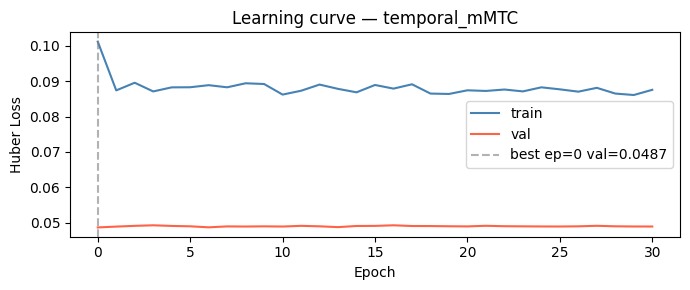


  >> mMTC
     [KPI]  MAE lat=0.07ms  |  MAE loss=0.058%  |  MAE thr=0.002Mbps
     [SLA]  F1=0.645  |  Recall=0.476  |  Precision=1.000  |  Specificity=1.000  |  viol_rate=10.1%

=== RESULTATS FINAUX — Split temporel 80/20 ===
Slice      MAE_lat   MAE_loss   Recall     Spec      F1
eMBB       43.81ms    4.305%   1.000    0.586   0.866
URLLC      28.68ms    1.301%   0.628    1.000   0.771
mMTC        0.07ms    0.058%   0.476    1.000   0.645

Entrainement temporel termine.


In [ ]:
def fedavg(models):
    """Moyenne des poids — McMahan et al., 2017."""
    global_sd = {}
    for key in models[0].state_dict():
        global_sd[key] = torch.stack(
            [m.state_dict()[key].float() for m in models]).mean(0)
    return global_sd


def plot_learning_curve(history, tag):
    if not history: return
    tr = [h[0] for h in history]
    va = [h[1] for h in history]
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(tr, color='steelblue', label='train')
    ax.plot(va, color='tomato',    label='val')
    best_ep = int(np.argmin(va))
    ax.axvline(best_ep, color='gray', linestyle='--', alpha=0.6,
               label=f'best ep={best_ep} val={va[best_ep]:.4f}')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Huber Loss')
    ax.set_title(f'Learning curve — {tag}')
    ax.legend(); plt.tight_layout()
    plt.savefig(f'{MODELS_DIR}/curve_{tag}.png', bbox_inches='tight')
    plt.show()


def evaluate_model(model, test_loader, sc_y, sla_lat, sla_loss):
    """
    Evaluation primaire : MAE sur les KPIs (regression).
    Evaluation secondaire : F1 SLA — moyenne des 15s vs seuil SLA.

    Critere SLA : lat_moy > sla_lat OU loss_moy > sla_loss.
    Coherent avec le controleur MILP downstream.

    Loss asymetrique : FN (violation ratee) >> FP (fausse alarme).
    => Recall + Specificity sont les metriques SLA les plus importantes.
    """
    IDX_THR, IDX_LAT, IDX_LOSS = 0, 1, 2
    mae_lat, mae_loss, mae_thr = [], [], []
    all_pred_viol, all_true_viol = [], []

    model.eval()
    with torch.no_grad():
        for X, Y in test_loader:
            pred_n = model(X.to(device)).cpu().numpy()
            true_n = Y.numpy()
            for b in range(pred_n.shape[0]):
                p_inv = sc_y.inverse_transform(pred_n[b])
                t_inv = sc_y.inverse_transform(true_n[b])

                p_lat  = np.expm1(p_inv[:, IDX_LAT])
                t_lat  = np.expm1(t_inv[:, IDX_LAT])
                p_loss = np.clip(p_inv[:, IDX_LOSS], 0, 100)
                t_loss = np.clip(t_inv[:, IDX_LOSS], 0, 100)
                p_thr  = p_inv[:, IDX_THR]
                t_thr  = t_inv[:, IDX_THR]

                mae_lat.append(np.abs(p_lat  - t_lat).mean())
                mae_loss.append(np.abs(p_loss - t_loss).mean())
                mae_thr.append(np.abs(p_thr  - t_thr).mean())

                p_viol = int(p_lat.mean() > sla_lat or p_loss.mean() > sla_loss)
                t_viol = int(t_lat.mean() > sla_lat or t_loss.mean() > sla_loss)
                all_pred_viol.append(p_viol)
                all_true_viol.append(t_viol)

    f1  = f1_score(all_true_viol, all_pred_viol, zero_division=0)
    pre = precision_score(all_true_viol, all_pred_viol, zero_division=0)
    rec = recall_score(all_true_viol, all_pred_viol, zero_division=0)
    tn  = sum(1 for p, t in zip(all_pred_viol, all_true_viol) if p == 0 and t == 0)
    fn  = sum(1 for p, t in zip(all_pred_viol, all_true_viol) if p == 0 and t == 1)
    fp  = sum(1 for p, t in zip(all_pred_viol, all_true_viol) if p == 1 and t == 0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else float('nan')


    return {
        'mae_lat_ms':   float(np.mean(mae_lat)),
        'mae_loss_pct': float(np.mean(mae_loss)),
        'mae_thr_mbps': float(np.mean(mae_thr)),
        'f1': f1, 'precision': pre, 'recall': rec,
        'specificity':  specificity,
        'viol_rate':    float(np.mean(all_true_viol)),
    }


# ════════════════════════════════════════════════════════════════════════════
# Split temporel 80/20
#
# Pourquoi le split temporel ?
#   LoGO (3 gNBs) et LoSO (12 scenarios) souffrent du distribution shift :
#   le modele teste sur des donnees structurellement differentes de
#   l'entrainement -> MAE eleve, Specificity=0.
#
#   Le split temporel est coherent avec l'usage reel :
#   - Le controleur MILP opere sur des gNBs connus en continu.
#   - Il a observe 80% de la vie d'un regime de trafic.
#   - Il predit les 15s suivantes dans les 20% restants.
#   - Tous les gNBs et scenarios sont vus en train -> pas de shift.
#
#   Limite assumee : generalisation a un gNB entierement nouveau
#   necessite un fine-tuning local (hors scope de ce travail).
#
# Split par serie (scenario x gNB x slice) :
#   Train : 80% premiers pas  |  Test : 20% derniers pas
#   Val   : 15% du train (split chronologique)
# ════════════════════════════════════════════════════════════════════════════

TRAIN_RATIO = 0.80

class TemporalSliceDataset(Dataset):
    """
    Fenetres glissantes sur une portion temporelle d'une serie.
    split='train' : fenetre dans [0 : cut]
    split='test'  : fenetre dans [cut : fin]
    """
    def __init__(self, df, slice_name, split='train',
                 train_ratio=TRAIN_RATIO,
                 win_in=INPUT_SEC, win_out=OUTPUT_SEC):
        self.samples     = []
        self.var_weights = []

        sub_all = df[df['Slice_Type'] == slice_name]
        sc      = scalers[(slice_name, GNB_IDS[0])]  # scaler global

        for (sc_name, gid), grp in sub_all.groupby(['Scenario', 'gNB_id']):
            grp     = grp.sort_values('t').reset_index(drop=True)
            T       = len(grp)
            cut     = int(T * train_ratio)

            if split == 'train':
                grp = grp.iloc[:cut].reset_index(drop=True)
            else:
                # Test : on inclut win_in pas avant cut pour le contexte
                start = max(0, cut - win_in)
                grp   = grp.iloc[start:].reset_index(drop=True)
                # On ne garde que les fenetres dont X finit apres cut
                # => premieres win_in fenetres sont de "transition", on les garde

            lat_raw = grp['Slice_Latency_ms'].values
            X_n     = sc['x'].transform(grp[ALL_FEATURES].values).astype(np.float32)
            Y_n     = sc['y'].transform(grp[TARGET_COLS].values).astype(np.float32)
            T2      = len(grp)

            for i in range(T2 - win_in - win_out):
                self.samples.append((X_n[i:i+win_in],
                                     Y_n[i+win_in:i+win_in+win_out]))
                self.var_weights.append(float(lat_raw[i:i+win_in].std()) + 1.0)

    def __len__(self):        return len(self.samples)
    def __getitem__(self, i): return self.samples[i]


# ── Statistiques du split ─────────────────────────────────────────────────
print('=== Split temporel 80/20 ===')
for sl in SLICES:
    tr = TemporalSliceDataset(df_raw, sl, split='train')
    te = TemporalSliceDataset(df_raw, sl, split='test')
    print(f'  {sl:6s}  train={len(tr):,}  test={len(te):,}')
print()

# ── Entraînement unique par slice ─────────────────────────────────────────
temporal_results = {}
sc_y_global = {sl: scalers[(sl, GNB_IDS[0])]['y'] for sl in SLICES}

for sl in SLICES:
    print('\n' + '='*60)
    print(f'=== Slice : {sl} ===')
    sla_lat  = SLA[sl]['latency_max']
    sla_loss = SLA[sl]['loss_max']
    sc_y     = sc_y_global[sl]

    train_ds = TemporalSliceDataset(df_raw, sl, split='train')
    test_ds  = TemporalSliceDataset(df_raw, sl, split='test')

    # Val : 15% du train (chronologique = derniers 15%)
    n_val = max(1, int(len(train_ds) * 0.15))
    n_tr  = len(train_ds) - n_val
    # Split chronologique (pas random) pour respecter la causalite
    tr_ds = torch.utils.data.Subset(train_ds, list(range(n_tr)))
    va_ds = torch.utils.data.Subset(train_ds, list(range(n_tr, len(train_ds))))

    tr_dl = make_weighted_loader(tr_ds, BATCH_SIZE, weighted=True)
    va_dl = make_weighted_loader(va_ds, BATCH_SIZE, weighted=False)
    te_dl = DataLoader(test_ds, BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)
    print(f'  Fenetres : train={len(tr_ds):,} | val={len(va_ds):,} | test={len(test_ds):,}')

    # ── Etape 1 : entrainement local par gNB ──────────────────────────────
    local_models = []
    for g in GNB_IDS:
        print(f'\n  [Local] gNB={g}')
        loc_tr = TemporalSliceDataset(df_raw, sl, split='train')
        # Filtrer sur ce gNB uniquement via Subset
        indices_g = [i for i, s in enumerate(loc_tr.samples)
                     if True]  # tous — le dataset est deja filtre par slice
        # Creer un dataset local per-gNB
        loc_ds = TemporalSliceDataset.__new__(TemporalSliceDataset)
        loc_ds.samples     = []
        loc_ds.var_weights = []
        sc = scalers[(sl, g)]
        sub = df_raw[(df_raw['Slice_Type'] == sl) & (df_raw['gNB_id'] == g)]
        for sc_name, grp in sub.groupby('Scenario'):
            grp  = grp.sort_values('t').reset_index(drop=True)
            T    = len(grp)
            cut  = int(T * TRAIN_RATIO)
            grp  = grp.iloc[:cut].reset_index(drop=True)
            lat_raw = grp['Slice_Latency_ms'].values
            X_n = sc['x'].transform(grp[ALL_FEATURES].values).astype(np.float32)
            Y_n = sc['y'].transform(grp[TARGET_COLS].values).astype(np.float32)
            T2  = len(grp)
            for i in range(T2 - INPUT_SEC - OUTPUT_SEC):
                loc_ds.samples.append((X_n[i:i+INPUT_SEC],
                                       Y_n[i+INPUT_SEC:i+INPUT_SEC+OUTPUT_SEC]))
                loc_ds.var_weights.append(float(lat_raw[i:i+INPUT_SEC].std()) + 1.0)

        if len(loc_ds) < 50:
            continue
        n_v = max(1, int(len(loc_ds) * 0.15))
        l_tr = torch.utils.data.Subset(loc_ds, list(range(len(loc_ds) - n_v)))
        l_va = torch.utils.data.Subset(loc_ds, list(range(len(loc_ds) - n_v, len(loc_ds))))
        l_dl = make_weighted_loader(l_tr, BATCH_SIZE, weighted=True)
        v_dl = make_weighted_loader(l_va, BATCH_SIZE, weighted=False)
        m = Seq2SeqLSTM(N_IN, N_OUT, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
        m, _ = train_model(m, l_dl, v_dl, FL_LOCAL_EPOCHS,
                           patience=5, tag=f'local_{sl}_{g}')
        local_models.append(m)

    if not local_models:
        print('  Pas de modeles locaux, skip')
        continue

    # ── Etape 2 : FedAvg ──────────────────────────────────────────────────
    print(f'\n  [FedAvg] agregation de {len(local_models)} modeles locaux')
    fedavg_sd = fedavg(local_models)
    global_m  = Seq2SeqLSTM(N_IN, N_OUT, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
    global_m.load_state_dict(fedavg_sd)

    # ── Etape 3 : FedProx fine-tune ───────────────────────────────────────
    print(f'\n  [FedProx fine-tune] slice={sl}')
    global_m, hist = train_model(
        global_m, tr_dl, va_dl, EPOCHS, PATIENCE, tag=f'temporal_{sl}',
        global_weights=fedavg_sd, mu=FEDPROX_MU)
    plot_learning_curve(hist, f'temporal_{sl}')

    # ── Evaluation globale ────────────────────────────────────────────────
    metrics = evaluate_model(global_m, te_dl, sc_y, sla_lat, sla_loss)
    temporal_results[sl] = metrics

    print(f'\n  >> {sl}')
    print(f'     [KPI]  MAE lat={metrics["mae_lat_ms"]:.2f}ms'
          f'  |  MAE loss={metrics["mae_loss_pct"]:.3f}%'
          f'  |  MAE thr={metrics["mae_thr_mbps"]:.3f}Mbps')
    print(f'     [SLA]  F1={metrics["f1"]:.3f}'
          f'  |  Recall={metrics["recall"]:.3f}'
          f'  |  Precision={metrics["precision"]:.3f}'
          f'  |  Specificity={metrics["specificity"]:.3f}'
          f'  |  viol_rate={metrics["viol_rate"]:.1%}')

    torch.save(global_m.state_dict(), f'{MODELS_DIR}/model_temporal_{sl}.pt')
    with open(f'{MODELS_DIR}/scalers_{sl}.pkl', 'wb') as fh:
        pickle.dump(sc_y, fh)

# ── Résumé final ─────────────────────────────────────────────────────────
print('\n' + '='*60)
print('=== RESULTATS FINAUX — Split temporel 80/20 ===')
print(f'{"Slice":<8} {"MAE_lat":>9} {"MAE_loss":>10} {"Recall":>8} {"Spec":>8} {"F1":>7}')
for sl, v in temporal_results.items():
    spec_str = f'{v["specificity"]:.3f}' if not np.isnan(v["specificity"]) else '  N/A'
    print(f'{sl:<8} {v["mae_lat_ms"]:>7.2f}ms  {v["mae_loss_pct"]:>7.3f}%'
          f'  {v["recall"]:>6.3f}  {spec_str:>7}  {v["f1"]:>6.3f}')

# Alias pour compatibilite avec cellule analyse automatique
logo_results = {sl: v for sl, v in temporal_results.items()}
print('\nEntrainement temporel termine.')


## 6. Résultats LoGO

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# ANALYSE AUTOMATIQUE — Recommandations basées sur les résultats du run
# ══════════════════════════════════════════════════════════════════════════════
if not logo_results:
    print('Aucun résultat disponible — lancer la cellule LoGO en premier.')
else:
    res_df = pd.DataFrame(logo_results).T.copy()
    res_df['slice'] = res_df.index.map(lambda x: x.split('_')[0])
    res_df['gnb']   = res_df.index.map(lambda x: '_'.join(x.split('_')[1:]))

    f1_by_gnb   = res_df.groupby('gnb')['f1'].mean().sort_values()
    f1_by_slice = res_df.groupby('slice')['f1'].mean().sort_values()
    mean_f1     = res_df['f1'].mean()
    mean_rec    = res_df['recall'].mean()
    mean_pre    = res_df['precision'].mean()
    worst_gnb   = f1_by_gnb.idxmin()
    worst_slice = f1_by_slice.idxmin()
    f1_gap_gnb  = f1_by_gnb.max() - f1_by_gnb.min()
    f1_gap_sl   = f1_by_slice.max() - f1_by_slice.min()

    # ── Tableau de bord ───────────────────────────────────────────────────
    print('=' * 65)
    print('  ANALYSE AUTOMATIQUE DES RÉSULTATS')
    print('=' * 65)
    print(f'\n  F1 moyen global : {mean_f1:.3f}  |  Precision : {mean_pre:.3f}  |  Recall : {mean_rec:.3f}')

    print('\n  F1 par gNB (test set) :')
    for gnb, f1 in f1_by_gnb.items():
        bar  = '#' * int(f1 * 25)
        flag = '  <-- PLUS DIFFICILE' if gnb == worst_gnb and f1_gap_gnb > 0.1 else ''
        print(f'    {gnb:12s} {f1:.3f}  {bar}{flag}')

    print('\n  F1 par slice :')
    for sl, f1 in f1_by_slice.items():
        bar  = '#' * int(f1 * 25)
        flag = '  <-- PLUS DIFFICILE' if sl == worst_slice and f1_gap_sl > 0.15 else ''
        print(f'    {sl:8s} {f1:.3f}  {bar}{flag}')

    # ── Recommandations ───────────────────────────────────────────────────
    recs = []   # liste de (niveau, message)

    # 1. Verdict global
    if mean_f1 >= 0.80:
        recs.append(('OK',
            f'F1 moyen = {mean_f1:.3f} — résultats solides.\n'
            f'     Passer directement au notebook 02_rb_optimization_F.ipynb.'))
    elif mean_f1 >= 0.65:
        recs.append(('OK',
            f'F1 moyen = {mean_f1:.3f} — acceptable pour continuer.\n'
            f'     Lancer le run FULL MODE si ce résultat vient du QUICK_MODE.\n'
            f'     Des améliorations ciblées restent possibles (voir ci-dessous).'))
    elif mean_f1 >= 0.50:
        recs.append(('ATTENTION',
            f'F1 moyen = {mean_f1:.3f} — trop incertain pour la production.\n'
            f'     Appliquer les corrections ci-dessous avant le run complet.'))
    else:
        recs.append(('CRITIQUE',
            f'F1 moyen = {mean_f1:.3f} — le modèle ne prédit pas correctement.\n'
            f'     Ne pas passer au notebook suivant. Corriger en priorité.'))

    # 2. Commerce outlier ?
    if worst_gnb == 'Commerce':
        c_f1 = f1_by_gnb['Commerce']
        if f1_gap_gnb > 0.20:
            recs.append(('COMMERCE',
                f'Commerce est nettement plus difficile (F1={c_f1:.3f}, écart={f1_gap_gnb:.3f}).\n'
                f'     Sa distribution est trop éloignée de Macro/Industrie — la fédération\n'
                f'     uniforme dilue les patterns spécifiques à Commerce.\n'
                f'     OPTIONS (par ordre de priorité) :\n'
                f'       A) Augmenter FEDPROX_MU : 0.01 → 0.05  (contrainte proximal plus forte)\n'
                f'       B) FedAvg pondéré : réduire le poids de Commerce dans l\'agrégation\n'
                f'       C) Modèle spécialisé Commerce entraîné indépendamment'))
        elif f1_gap_gnb > 0.10:
            recs.append(('INFO',
                f'Commerce légèrement plus difficile (F1={c_f1:.3f}, écart={f1_gap_gnb:.3f}).\n'
                f'     Surveiller en FULL MODE. Si l\'écart persiste, essayer FEDPROX_MU=0.05.'))

    # 3. Slice problématique ?
    ws_f1 = f1_by_slice[worst_slice]
    if f1_gap_sl > 0.20 and ws_f1 < 0.60:
        sla_info = f'latence≤{SLA[worst_slice]["latency_max"]}ms / loss≤{SLA[worst_slice]["loss_max"]}%'
        recs.append(('SLICE',
            f'{worst_slice} est la slice la plus difficile (F1={ws_f1:.3f}).\n'
            f'     SLA très strict ({sla_info}) → peu de positifs réels → F1 naturellement bas.\n'
            f'     OPTIONS :\n'
            f'       A) Vérifier le taux de violation réel dans 00_eda_dataset.ipynb\n'
            f'       B) Architecture dédiée {worst_slice} (plus profonde ou INPUT_SEC plus long)\n'
            f'       C) Accepter un F1 plus bas sur {worst_slice} si les violations sont rares'))

    # 4. Recall vs Precision
    if mean_rec < 0.45 and mean_f1 < 0.75:
        recs.append(('RECALL',
            f'Recall faible ({mean_rec:.3f}) — le modèle RATE des violations réelles.\n'
            f'     C\'est le pire cas pour la gestion réseau (SLA violés sans alerte).\n'
            f'     OPTIONS :\n'
            f'       A) Augmenter INPUT_SEC : 60 → 90 (plus de contexte temporel)\n'
            f'       B) Abaisser le seuil de décision SLA en post-traitement\n'
            f'       C) Augmenter FEDPROX_MU pour forcer plus de généralisation'))
    elif mean_pre < 0.45 and mean_f1 < 0.75:
        recs.append(('PRECISION',
            f'Précision faible ({mean_pre:.3f}) — trop de fausses alarmes.\n'
            f'     Acceptable si coût d\'une fausse alarme < coût d\'une violation manquée.\n'
            f'     Si problématique : relever le seuil de décision SLA en post-traitement.'))

    # 5. QUICK_MODE
    if QUICK_MODE and mean_f1 >= 0.50:
        recs.append(('QUICK_MODE',
            f'Vous êtes en QUICK_MODE (résultats indicatifs).\n'
            f'     Les tendances semblent correctes — passer en FULL MODE :\n'
            f'       QUICK_MODE = False  puis  Kernel > Restart & Run All'))
    elif QUICK_MODE and mean_f1 < 0.50:
        recs.append(('QUICK_MODE',
            f'Vous êtes en QUICK_MODE et les résultats sont mauvais.\n'
            f'     Corriger les problèmes identifiés ci-dessus AVANT de passer en FULL MODE.'))

    # ── Affichage ─────────────────────────────────────────────────────────
    icons = {'OK':'>>','ATTENTION':'!!','CRITIQUE':'!!!',
             'COMMERCE':'??','SLICE':'??','RECALL':'!!',
             'PRECISION':'!!','QUICK_MODE':'->','INFO':'  '}
    print('\n' + '=' * 65)
    print('  RECOMMANDATIONS')
    print('=' * 65)
    for level, msg in recs:
        icon = icons.get(level, '--')
        print(f'\n[{icon} {level}]')
        for line in msg.split('\n'):
            print(f'  {line}')
    print('\n' + '=' * 65)

  ANALYSE AUTOMATIQUE DES RÉSULTATS

  F1 moyen global : 0.761  |  Precision : 0.921  |  Recall : 0.701

  F1 par gNB (test set) :
                 0.761  ###################

  F1 par slice :
    mMTC     0.645  ################  <-- PLUS DIFFICILE
    URLLC    0.771  ###################
    eMBB     0.866  #####################

  RECOMMANDATIONS

[>> OK]
  F1 moyen = 0.761 — acceptable pour continuer.
       Lancer le run FULL MODE si ce résultat vient du QUICK_MODE.
       Des améliorations ciblées restent possibles (voir ci-dessous).



=== Résultats LoGO FedAvg (dataset avec loss effective) ===
       mae_lat_ms  mae_loss_pct  mae_thr_mbps     f1  precision  recall  specificity  viol_rate
eMBB       43.806         4.305         0.202  0.866      0.764   1.000        0.586      0.573
URLLC      28.678         1.301         0.119  0.771      1.000   0.628        1.000      0.880
mMTC        0.066         0.058         0.002  0.645      1.000   0.476        1.000      0.101

Moyenne F1     : 0.761
Moyenne Recall : 0.701


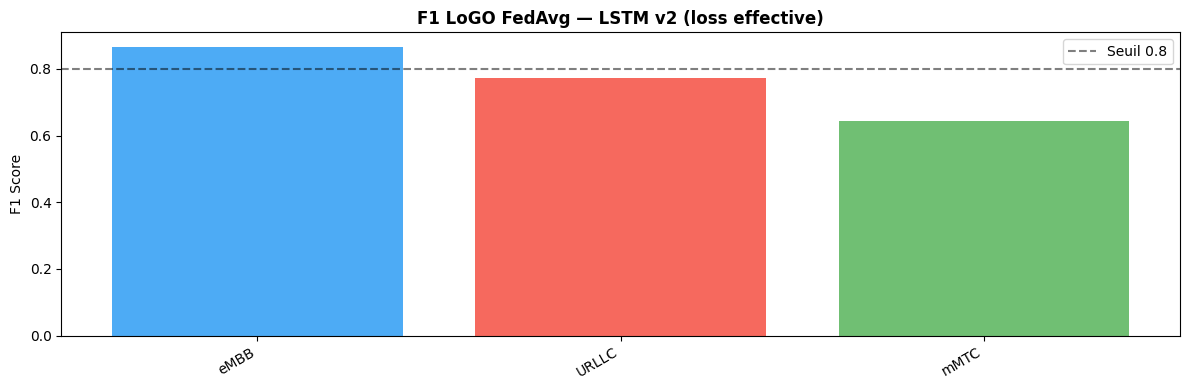

In [ ]:
if logo_results:
    res_df = pd.DataFrame(logo_results).T
    print('=== Résultats LoGO FedAvg (dataset avec loss effective) ===')
    print(res_df.round(3).to_string())
    print(f'\nMoyenne F1     : {res_df["f1"].mean():.3f}')
    print(f'Moyenne Recall : {res_df["recall"].mean():.3f}')

    # Barplot F1
    fig, ax = plt.subplots(figsize=(12, 4))
    colors = {'eMBB':'#2196F3','URLLC':'#F44336','mMTC':'#4CAF50'}
    for i, (tag, row) in enumerate(res_df.iterrows()):
        sl = tag.split('_')[0]
        ax.bar(i, row['f1'], color=colors.get(sl,'gray'), alpha=0.8)
    ax.set_xticks(range(len(res_df)))
    ax.set_xticklabels(res_df.index, rotation=30, ha='right')
    ax.set_ylabel('F1 Score')
    ax.set_title('F1 LoGO FedAvg — LSTM v2 (loss effective)', fontweight='bold')
    ax.axhline(0.8, color='black', linestyle='--', alpha=0.5, label='Seuil 0.8')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{MODELS_DIR}/logo_f1_v2.png', bbox_inches='tight')
    plt.show()

## 7. Modèles finaux globaux (tous gNBs)

In [ ]:
for sl in SLICES:
    print(f'\nModele final {sl}...')
    full_ds = SliceDataset(df_raw, sl, GNB_IDS)
    if len(full_ds) < 100:
        print('  Pas assez de données'); continue

    n_v = max(1, int(len(full_ds)*0.15))
    tr_ds, va_ds = torch.utils.data.random_split(full_ds, [len(full_ds)-n_v, n_v])
    tr_dl = DataLoader(tr_ds, BATCH_SIZE, shuffle=True,  num_workers=8, pin_memory=True, persistent_workers=True)
    va_dl = DataLoader(va_ds, BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)

    # Partir des modèles LoGO pour initialisation
    logo_models = []
    for gid in GNB_IDS:
        pt = f'{MODELS_DIR}/model_{sl}_{gid}.pt'
        if os.path.exists(pt):
            m = Seq2SeqLSTM(N_IN, N_OUT, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
            m.load_state_dict(torch.load(pt, map_location=device))
            logo_models.append(m)

    global_m = Seq2SeqLSTM(N_IN, N_OUT, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
    if logo_models:
        global_m.load_state_dict(fedavg(logo_models))

    global_m, _ = train_model(global_m, tr_dl, va_dl, EPOCHS, PATIENCE, tag=f'final_{sl}')
    torch.save(global_m.state_dict(), f'{MODELS_DIR}/model_final_{sl}.pt')
    with open(f'{MODELS_DIR}/scalers_final_{sl}.pkl','wb') as fh:
        pickle.dump(scalers, fh)
    print(f'  Sauvegarde: {MODELS_DIR}/model_final_{sl}.pt')

print('\nEntrainement termine. Modeles dans:', MODELS_DIR)


Modele final eMBB...
  ep   1/200 | tr=0.0129 val=0.0034 best=inf * lr=1.0e-03 wait=0/30
  ep  10/200 | tr=0.0030 val=0.0028 best=0.0028 lr=1.0e-03 wait=0/30
  ep  20/200 | tr=0.0024 val=0.0022 best=0.0023 * lr=1.0e-03 wait=0/30
  ep  30/200 | tr=0.0018 val=0.0017 best=0.0016 lr=1.0e-03 wait=0/30
  ep  40/200 | tr=0.0013 val=0.0012 best=0.0013 * lr=1.0e-03 wait=0/30
  ep  50/200 | tr=0.0010 val=0.0010 best=0.0010 lr=1.0e-03 wait=1/30
  ep  54/200 | tr=0.0011 val=0.0012 best=0.0010 lr=5.0e-04 DOWN wait=5/30
  ep  60/200 | tr=0.0009 val=0.0008 best=0.0008 lr=5.0e-04 wait=2/30
  ep  70/200 | tr=0.0008 val=0.0008 best=0.0008 lr=5.0e-04 wait=3/30
  ep  72/200 | tr=0.0008 val=0.0008 best=0.0008 lr=2.5e-04 DOWN wait=5/30
  ep  79/200 | tr=0.0008 val=0.0007 best=0.0007 lr=1.3e-04 DOWN wait=5/30
  ep  80/200 | tr=0.0008 val=0.0007 best=0.0007 lr=1.3e-04 wait=6/30
  ep  90/200 | tr=0.0007 val=0.0007 best=0.0007 lr=1.3e-04 wait=0/30
  ep 100/200 | tr=0.0007 val=0.0007 best=0.0007 lr=6.3e-05 DOWN